# Importing data and libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from osgeo import gdal
from sklearn.metrics import r2_score
from scipy.interpolate import RegularGridInterpolator
from scipy.signal import find_peaks

import xarray as xr
from scipy import signal
from osgeo import gdal

In [2]:
# NEED TO FIX THIS BEFORE SUBMISSION
# This chunk of code ensures the current working directory is in the correct place to read and import the script file

import sys
sys.path.append("/Users/pia/Desktop/honours/VIEPS/") # note to self before submission: change this to work for anyone who downloads this

#% is a magic command, special shortcut command that lets you control/interact with notebook environment (ie. gives control of terminal without writing full python code)
%cd .

!pwd

# note: import_substation.py written by Mathew Lipson

/Users/pia/Desktop/honours/VIEPS/Data_Analysis
/Users/pia/Desktop/honours/VIEPS/Data_Analysis


In [3]:
# This line of code controls/interacts with the notebook environment/terminal, and runs the import_substation script that imports the dataframe
%run ./import_substation.py

# the variables outputted are:
    # demand = electricity demand
    # obs = temperature observations
    # info = metadata

processing nsw substations for ['ausgrid'] from None to None
ausgrid
following columns in demand are not in info index:
['MT_HU', 'SI_NO']
removing these columns from demand
number of substations in ausgrid substation info: 134
number of substations in ausgrid substation data: 132
following sites match selection criteria:
               energy_asset          Name  Area  Dwellings  Persons  Residential  Commercial  Industrial  Primary Production  Education  \
ID                                                                                                                                        
BLAKE         AG_BLAKEHURST    Blakehurst     7      10081    28521        0.850       0.005       0.021               0.000      0.022   
PUNCH          AG_PUNCHBOWL     Punchbowl     9      17514    50395        0.826       0.048       0.038               0.000      0.025   
MEADO         AG_MEADOWBANK    Meadowbank    15      22420    56948        0.825       0.023       0.015               0

# Plot 1 - Daily Mean Temperature in Meadowbank Against Daily Mean Electricity Demand with Quadratic Regression

## Define functions

In [4]:
def get_r2(x,y):
    polyfit = np.polyfit(x,y,1) # can define own function of y (f(x)) in previous function and derive using different function
    y_predicted = np.polyval(polyfit,x) # 1 - (sum squares of residuals)/(sum total squares)
    residuals = y-y_predicted
    return 1-np.sum(residuals**2)/np.sum((y-np.mean(y))**2)

## Ensuring time is in datetime format for both demand and temperature

In [5]:
# converting the index from demand into datetime index just incase, and sorting so they can be matched up
demand.index = pd.to_datetime(demand.index) # making the index datetime
demand = demand.sort_index() # ensuring index is in chronological order

# same as above but for temperature
obs.index = pd.to_datetime(obs.index)
obs = obs.sort_index()

In [6]:
# merging the obs and demand into one dataframe for MEADO (one location)
merged = obs[['t2m']].join(demand[['MEADO']], how='inner')

## Downsampling from 30 minute to daily 

In [7]:
# demand resampling and computing the daily mean
demand_daily = demand[['MEADO']].resample('D').mean()

# obs resampled and computing the daily mean
obs_daily = obs[['t2m']].resample('D').mean()

In [8]:
# merging daily dataframes
merged = obs_daily.join(demand_daily, how='inner') 

## Test plotting daily temperautre vs demand

Text(0.5, 1.0, 'Daily Mean Temperature in Meadowbank Against Daily Mean Electricity Demand')

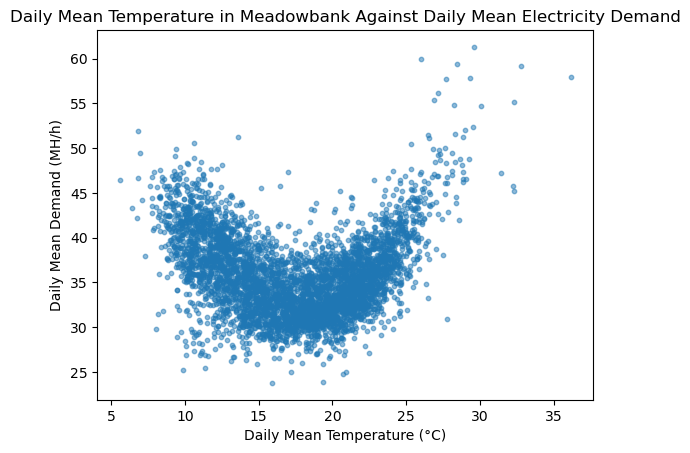

In [9]:
# renaming for clarity
temp_daily = merged['t2m']
demand_daily = merged['MEADO']

# test plotting scatter daily mean tmp vs daily mean demand
plt.scatter(temp_daily, demand_daily, s=10, alpha=0.5)
plt.xlabel('Daily Mean Temperature (°C)')
plt.ylabel('Daily Mean Demand (MH/h)')
plt.title('Daily Mean Temperature in Meadowbank Against Daily Mean Electricity Demand')

## Getting r^2 value

In [10]:
# setting x and y values
x = temp_daily
y = demand_daily

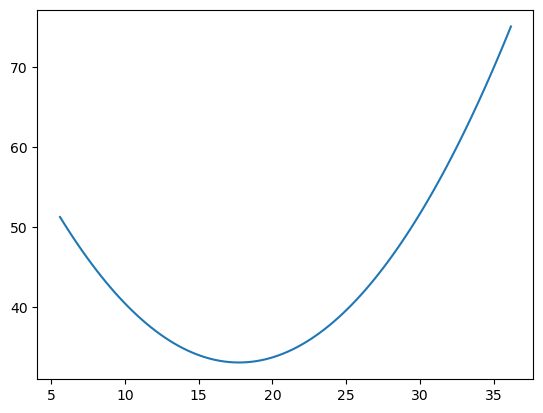

In [11]:
# having to create a clean dataframe by dropping any NaN values from each temp and demand daily dataframes
clean_df = pd.DataFrame({
    "temp": temp_daily,
    "demand": demand_daily
}).dropna()

x_values = clean_df["temp"].values # setting x_values
y_values = clean_df["demand"].values # setting y_values

coeffs = np.polyfit(x_values, y_values, 2) 
# fitting the model to x and y values
# the formula of the curve

x_range = np.linspace(x.min(), x.max(), 100) 
# creating lineraly interval array for the x range with 100 values (minimum temperature to the maximum temperature)
# the x‑positions where you want the curve

y_fit = np.polyval(coeffs, x_range) 
# evaluates the quadratic model at these x values (temperature)
# the y‑values of the curve

plt.plot(x_range, y_fit) # plotting the fitted regression quadratic line to test if working

## Final Plotting

In [12]:
# setting up plotting functions to ensure they are at a publishing standard (stylising)
%matplotlib inline
plt.rcParams['font.sans-serif'] = 'Arial' # Choose a nice font here
plt.rcParams['font.size'] = 7 # standard font size
plt.rcParams.update({'font.size': 12})
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial'
plt.rcParams['figure.facecolor'] = 'white' # make sure background isn't transparent
plt.rcParams['figure.dpi'] = 100
# https://www.nature.com/documents/Final_guide_to_authors.pdf

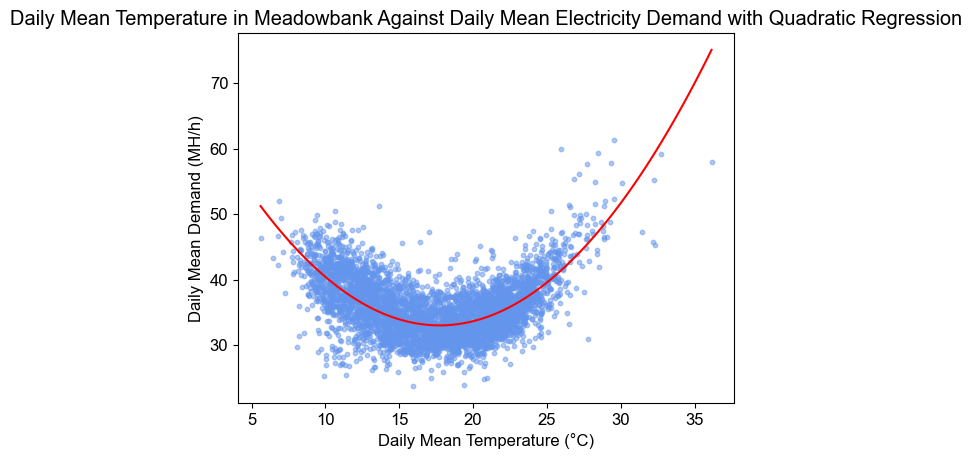

In [13]:
# plotting the regression line over the scatter

plt.scatter(temp_daily, demand_daily, s=10, alpha=0.5, c='cornflowerblue')
plt.xlabel('Daily Mean Temperature (°C)')
plt.ylabel('Daily Mean Demand (MH/h)')
plt.title('Daily Mean Temperature in Meadowbank Against Daily Mean Electricity Demand with Quadratic Regression')

plt.plot(x_range, y_fit, c='red')


### Adding minimum temperature and r^2 value to plot

In [14]:
# calculating R^2 value
y_predicted_quad = np.polyval(coeffs, x_values) # calculated r^2
r2 = r2_score(y_values, y_predicted_quad) # assigning the value to a variable r2 for plotting

# Finding the x value (temperature) and the minimum y value (demand)
min_idx = np.argmin(y_fit) # finds the index of the lowest value of the fitted curve 
min_temp = x_range[min_idx] # uses the index found above to look at the temperature value at that minimum
min_demand = y_fit[min_idx] # uses index to look at the demand value at that minimum

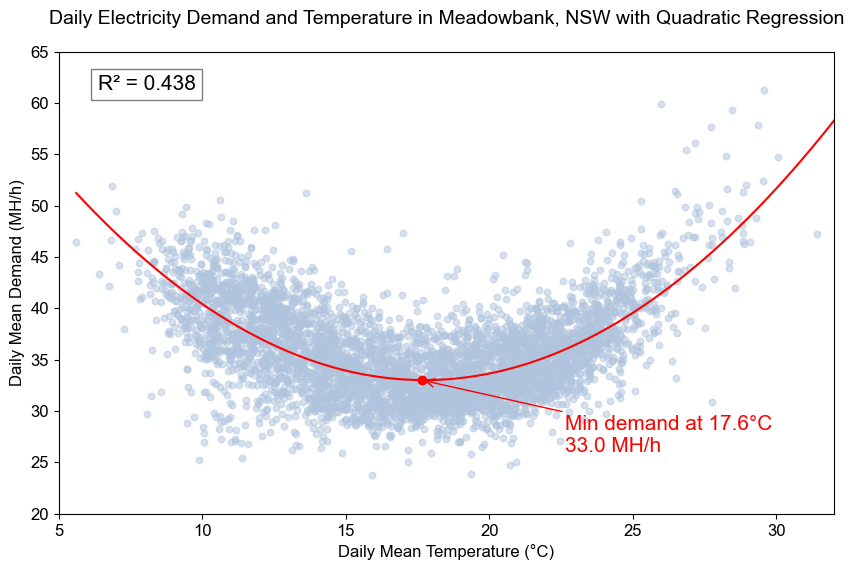

In [15]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6)) # setting figure size
ax.scatter(x_values, y_values, s=22, alpha=0.5, c='lightsteelblue') # scatter plot, light steel blue chosen so the quadratic line is visible
ax.plot(x_range, y_fit, c='red') # regression line


ax.plot(min_temp, min_demand, 'ro', markersize=6)
ax.annotate( # adds a text label with an arrow to the plot
    f'Min demand at {min_temp:.1f}°C\n{min_demand:.1f} MH/h', # text that will be displayed on plot
    xy=(min_temp, min_demand),                    # the point the arrow points TO (the actual data point)
    xytext=(min_temp + 5, min_demand - 7),        # text box position from data point
    arrowprops=dict(arrowstyle='->', color='red'),# red arrow
    fontsize=15,                                
    color='red'                                  
)

# stylising r^2 text/text box to be top right, larger text to be legible 
ax.text(0.05, 0.95, f'R² = {r2:.3f}',
        transform=ax.transAxes,
        fontsize=15,
        verticalalignment='top',
        bbox=dict(boxstyle='square', facecolor='white', alpha=0.5))

# setting main title, x limits and y limits
ax.set_xlabel('Daily Mean Temperature (°C)')
# to show data more clearly and remove any unnecessary white space
ax.set_xlim(5,32)
ax.set_ylim(20,65)

ax.set_ylabel('Daily Mean Demand (MH/h)')
ax.set_title('Daily Electricity Demand and Temperature in Meadowbank, NSW with Quadratic Regression', 
             fontsize=14, pad=20) # pad gives space between title and plot

# plt.savefig('daily_mean_temp_quad_regres.png', dpi=300, bbox_inches='tight') saving the figure (turned off)
plt.show()

### Adding seasonal colours
- clearly show relationship between temperature, demand and seasons variation

In [16]:
# Assigning month information to the clean temp and demand dataframe
clean_df['month'] = clean_df.index.month

# creating a season dictionary to map each month to the correct season observed in meadowbank, NSW 
# eg. 12 (dec) = Summer, 1 (Jan) = Summer etc.
season_map = {12: 'Summer', 1: 'Summer', 2: 'Summer',
              3: 'Autumn',  4: 'Autumn',  5: 'Autumn',
              6: 'Winter',  7: 'Winter',  8: 'Winter',
              9: 'Spring',  10: 'Spring', 11: 'Spring'}

# assigning each season with a custom chosen colour
season_colours = {
    'Summer': '#c02b36',
    'Autumn': '#E67E22',
    'Winter': '#2980B9',
    'Spring': '#27AE60'
}

# assigning the actual datapoints to a season and colour from dictionary above
clean_df['season'] = clean_df['month'].map(season_map) #create column season, and assign it to the correct month
clean_df['colour'] = clean_df['season'].map(season_colours) # uses the season column and assigns the colour to the correct month/season

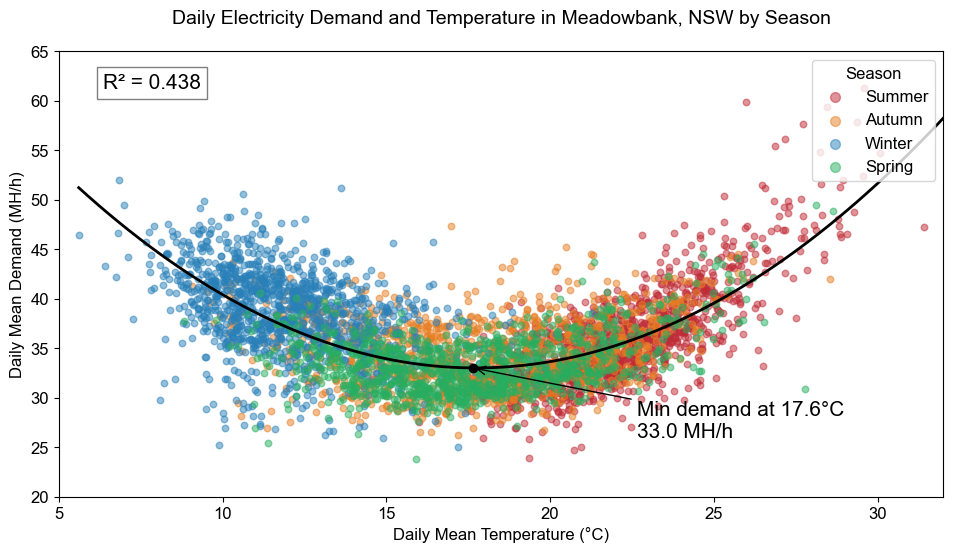

In [17]:
fig, ax = plt.subplots(figsize=(10, 6)) # setting up figure

# Plotting each season separately for the legend
for season, colour in season_colours.items(): # loops through the season mask created above and assigns the datapoints to a colour
    mask = clean_df['season'] == season
    ax.scatter(clean_df.loc[mask, 'temp'], clean_df.loc[mask, 'demand'],
               s=22, alpha=0.5, c=colour, label=season)

#  plotting quadratic line (this time in black due to many colours from seasons, otherwise same as above)
ax.plot(x_range, y_fit, c='black', linewidth=2)
ax.plot(min_temp, min_demand, 'ko', markersize=6)
ax.annotate(
    f'Min demand at {min_temp:.1f}°C\n{min_demand:.1f} MH/h',
    xy=(min_temp, min_demand),
    xytext=(min_temp + 5, min_demand - 7),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=15,
    color='black'
)
# r^2 text box
ax.text(0.05, 0.95, f'R² = {r2:.3f}',
        transform=ax.transAxes,
        fontsize=15,
        verticalalignment='top',
        bbox=dict(boxstyle='square', facecolor='white', alpha=0.5))

#season legend
ax.legend(title='Season', loc='upper right', markerscale=1.5)

ax.set_xlabel('Daily Mean Temperature (°C)')
ax.set_xlim(5, 32)
ax.set_ylim(20, 65)
ax.set_ylabel('Daily Mean Demand (MH/h)')
ax.set_title('Daily Electricity Demand and Temperature in Meadowbank, NSW by Season',
             fontsize=14, pad=20)

plt.tight_layout(pad=2.0)
plt.show()

# Plot 2 - Spectral Analysis

## Functions

In [18]:
def get_powerlaw_constants(x,y):
    # assumes a model y = l * x**n
    # l is the prefactor, n is the exponent (slope in log scale)
    # log slope is power-law relationship
    # uses polyfit
    # take long of x and y and fit a straight line
    polyfit = np.polyfit(np.log10(x),np.log10(y),1)
    # recover the constants
    l,n = 10**polyfit[1],polyfit[0]
    return l,n

In [19]:
# Converting sections to years
s_to_yrs = 1/(60*60*24*365)

## Setting up

In [20]:
# extract demand and time values as arrays
demand_meado = demand["MEADO"].values # extracting demand from just meadowbank
time = demand.index.values 

# build mask: keep only values that are not NaN and not zero
mask = (~np.isnan(demand_meado)) & (demand_meado != 0)

# apply cleaning mask to both arrays
demand_clean = demand_meado[mask]
time_clean = time[mask]

# printing the dataframes to ensure they have the same amount of values
print(len(demand_clean), len(time_clean))

201545 201545


In [21]:
# converting timestamps to seconds when start
time_seconds = (time_clean - time_clean.min()) / np.timedelta64(1, 's')

### Practice plotting
- checking time to seconds and year conversion worked

Text(0, 0.5, 'Demand (MW/h)')

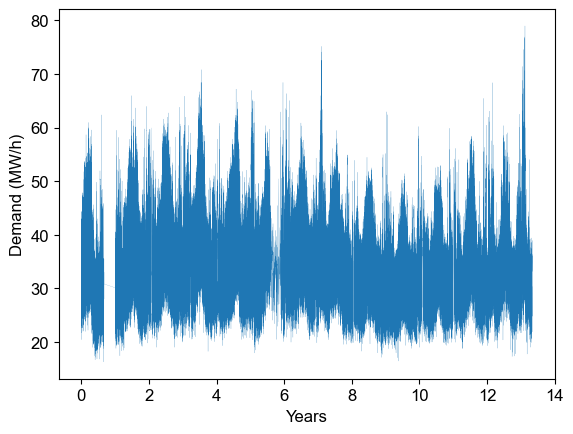

In [22]:
plt.plot(time_seconds*s_to_yrs, demand_clean, lw=0.1)
plt.xlabel('Years')
plt.ylabel('Demand (MW/h)')

## Welch Calculations and plotting

In [23]:
# creating frequency and power spectral variables using welch calculations
# to determine if any cyclical patterns in demand

freq, psd = signal.welch(demand_clean, 1/np.diff(time_seconds)[0], nperseg=len(time), scaling='spectrum') # raw
freq_smooth, psd_smooth = signal.welch(demand_clean, 1/np.diff(time_seconds)[0], nperseg=int(1/s_to_yrs/np.diff(time_seconds)[0]/12), scaling='spectrum') # smooth

/var/folders/gs/wb_c1_3s3mq7bqc05wjgf8bw0000gn/T/ipykernel_44855/1037967420.py:4: UserWarning: nperseg=205655 is greater than signal length max(len(x), len(y)) = 201545, using nperseg = 201545
  freq, psd = signal.welch(demand_clean, 1/np.diff(time_seconds)[0], nperseg=len(time), scaling='spectrum') # raw


Text(0.5, 1.0, 'Power Spectra with a frequency in seconds for Meadowbank')

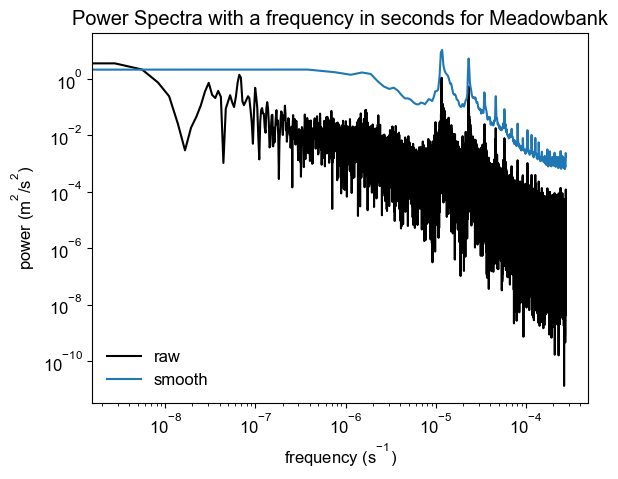

In [24]:
# plotting power spectra, the full one (black = very noise) but full range of power
# smooth = seconds to years

plt.plot(freq, psd,'k',label='raw') # raw, k makes the line black
plt.plot(freq_smooth, psd_smooth, label='smooth') # smooth, blue link
plt.xscale('log') # converting x to log scale
plt.yscale('log') # converting y to log scale
plt.xlabel('frequency (s$^{-1}$)')
plt.ylabel('power (m$^2$/s$^2$)')
# commenting out x and y axis restricting to see full image
# plt.xlim(10e-6, 10**(-3.5))
# plt.ylim(1e-4,5e1)
plt.legend(loc=0,frameon=False)
plt.title('Power Spectra with a frequency in seconds for Meadowbank')

## Final plotting
- limiting x axis to remove any unneccesary white space
- only showing smooth line
- adding in annotations
    - annotating the two major peaks
      - converting the x scale to a meaningful number (ie. days/hours)

/var/folders/gs/wb_c1_3s3mq7bqc05wjgf8bw0000gn/T/ipykernel_44855/1945220676.py:2: RuntimeWarning: divide by zero encountered in divide
  ax.plot(s_to_yrs/freq_smooth, psd_smooth, label="Smooth") # plotting just the smooth spectral analysis


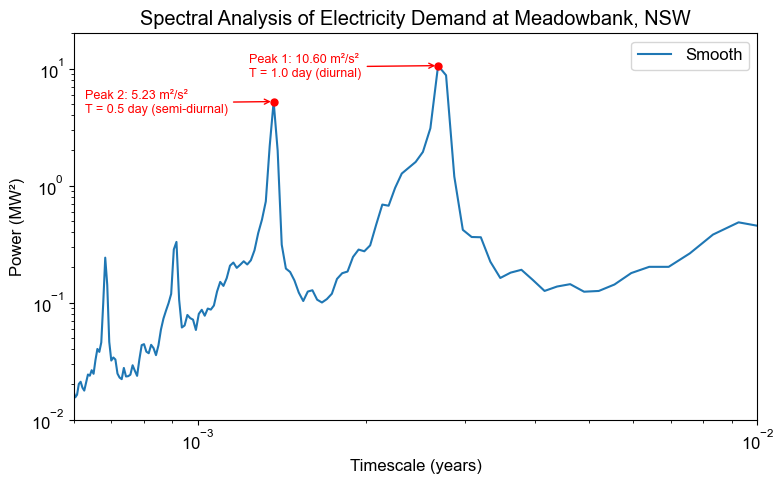

In [25]:
fig, ax = plt.subplots(figsize=(8, 5)) # 
ax.plot(s_to_yrs/freq_smooth, psd_smooth, label="Smooth") # plotting just the smooth spectral analysis

# Find the values of the peaks and add annotations
peaks, _ = find_peaks(psd_smooth, prominence=0.01) # finding the peaks
top2_idx = peaks[np.argsort(psd_smooth[peaks])[-2:]][::-1]  # sorts largest first
labels = ['diurnal', 'semi-diurnal'] # creating labels

for i, idx in enumerate(top2_idx): # looping through the two peak values
    peak_x_years = s_to_yrs / freq_smooth[idx] # converts frequency at the timescale into years
    peak_x_days = peak_x_years * 365 # converting into days
    peak_y = psd_smooth[idx] # y position of the annotation at the peak power value
    
    ax.plot(peak_x_years, peak_y, 'ro', markersize=5) # adding the annotation to the plot
    ax.annotate(
        f'Peak {i+1}: {peak_y:.2f} m²/s²\nT = {peak_x_days:.1f} day ({labels[i]})', # label text
        xy=(peak_x_years, peak_y), # assigning x, y values
        xytext=(peak_x_years * 0.46, peak_y * 0.8),
        arrowprops=dict(arrowstyle='->', color='red'),
        fontsize=9,
        color='red'
    )

# setting x and y limits to show peaks in better detail
ax.set_xlim(6e-4, 1e-2)
ax.set_ylim(1e-2, 2e1)
# log for x and y
ax.set_xscale("log")
ax.set_yscale("log")
# labelling and titling
ax.set_xlabel("Timescale (years)")
ax.set_ylabel("Power (MW²)")
ax.legend()
ax.set_title('Spectral Analysis of Electricity Demand at Meadowbank, NSW')
plt.tight_layout()

# plt.savefig('spectral_analysis_meadowbank.png', dpi=400, bbox_inches='tight') saving command but commenting out
plt.show()